In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import tplquad
from scipy.special import spherical_jn

### the complete integral

$$U_D(R) = \int^\infty _0 \int^\infty _0 \int^\infty _0 k^2 j_0(kR) v_D(k) F(\rho) g(E)   r_1^2 j_0(kr_1) \rho_p(r_1)  r_2^2 j_0(kr_2) \rho_t(r_2) dk dr_1 dr_2$$

In [2]:
def integrate(k, r2, r1,
              R,
              c1=11061.625,
              c2=2537.5,
              c=1.2521,
              mu1=4,
              mu2=2.5,
              gamma=1.7452,
              n=1):

    # Density functions
    def density_p(r):
        return 0.4229*np.exp(-0.7024 * r**2)

    def density_t(r, rho_0=0.172, a=0.540, R_0 = 4.094):
        return rho_0/(1+np.exp((r-R_0)/a))
    
    # g(E)
    def g(E_lab, A=4):
        return (1-0.003*E_lab/A)

    # Total density
    rho = density_p(r1) + density_t(r2)

    # Fourier transform of M3Y interaction
    vD = (
        (4*np.pi*c1/mu1) / (mu1**2 + k**2)
        -
        (4*np.pi*c2/mu2) / (mu2**2 + k**2)
    )

    # Density-dependent factor
    F = c * (1 - gamma * rho**n)

    return 8*(
        k**2
        * spherical_jn(0, k*R)
        * vD
        * F
        * g(E_lab=200)
        * r1**2
        * r2**2
        * spherical_jn(0, k*r1)
        * spherical_jn(0, k*r2)
        * density_p(r1)
        * density_t(r2)
    )

In [3]:
R_vals = np.array([0.5*i for i in range(17)])

In [4]:
datas = []
errors = []

In [5]:
for i in range(0,17):

    result, error = tplquad(
        integrate,

        # r1: outer integral
        0, 5,

        # r2: middle integral
        lambda r1: 0,
        lambda r1: 8,

        # k: inner integral
        lambda r1, r2: 0,
        lambda r1, r2: 4,

        args=(R_vals[i],)
    )
    
    datas.append(result)
    errors.append(error)

In [6]:
len(datas)

17

In [7]:
R = np.linspace(0,8,17)

In [8]:
datas

[46.55822343597939,
 46.916328522881464,
 47.91414016847312,
 49.287060864714725,
 50.43148683902765,
 50.325590122572116,
 47.85090765714559,
 42.3098626439454,
 33.76499266588353,
 23.27688922044214,
 12.892977160139333,
 4.82507287618653,
 0.16267794254683088,
 -1.5744168681009927,
 -1.660051148061848,
 -1.1827109342960782,
 -0.6989045433818848]

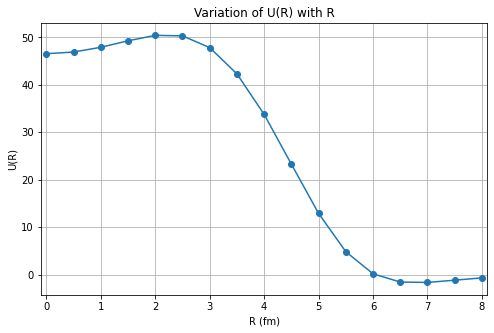

In [9]:
R_vals = np.array([0.5*i for i in range(17)])

plt.figure(figsize=(8, 5))

plt.plot(R_vals, datas, marker='o')

plt.xlabel('R (fm)')
plt.ylabel('U(R)')
plt.title('Variation of U(R) with R')
plt.xlim(-0.1,8.1)

plt.grid(True)
plt.show()